#  Summary Report
## Recruitment NLP Lab — Notebook 06: Final Observations & Metrics

This notebook aggregates results from all previous notebooks into one
consolidated summary — metrics, observations, and final insights.

**Prerequisites:** Notebooks 01–05 must have been run in order.
All saved artifacts are loaded from `data/processed/` and `results/`.

In [2]:
!py -3.11 -m pip install scikit-learn pandas numpy matplotlib seaborn tensorflow


[notice] A new release of pip is available: 23.1.2 -> 26.0.1
[notice] To update, run: C:\Users\Dell\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


## 1. Import Libraries & Load All Artifacts

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, os, json
import scipy.sparse as sp

from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, f1_score)
from sklearn.preprocessing import LabelEncoder

import tensorflow as tf
from tensorflow import keras

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
print("   Libraries loaded!")
print(f"   TensorFlow : {tf.__version__}")

   Libraries loaded!
   TensorFlow : 2.20.0


In [2]:
# ── Cleaned datasets ──────────────────────────────────────────────
resumes = pd.read_csv("../data/processed/resumes_cleaned.csv")
jobs    = pd.read_csv("../data/processed/jobs_cleaned.csv")

resume_levels = pd.read_csv("../data/processed/resume_with_levels.csv")
resumes = resumes.merge(
    resume_levels[['ID', 'experience_level']],
    on='ID', how='left'
)

# ── TF-IDF matrices ───────────────────────────────────────────────
resume_matrix = sp.load_npz("../data/processed/resume_tfidf_matrix.npz")

# ── Encoders ──────────────────────────────────────────────────────
with open("../data/processed/label_encoder.pkl", "rb") as f:
    cat_encoder = pickle.load(f)
with open("../data/processed/exp_level_encoder.pkl", "rb") as f:
    exp_encoder = pickle.load(f)

# ── Models ────────────────────────────────────────────────────────
cat_model = keras.models.load_model("../results/models/best_category_classifier.keras")
exp_model = keras.models.load_model("../results/models/best_exp_classifier.keras")

# ── Test splits ───────────────────────────────────────────────────
X_test      = np.load("../data/processed/X_test.npy")
y_test_cat  = np.load("../data/processed/y_test_cat.npy")
X_exp_test  = np.load("../data/processed/X_exp_test.npy")
y_exp_test  = np.load("../data/processed/y_exp_test.npy")

# ── Match results ─────────────────────────────────────────────────
matches_df  = pd.read_csv("../results/metrics/all_matches.csv")
filtered_df = pd.read_csv("../results/metrics/filtered_matches.csv")

print("All artifacts loaded!")
print(f"   Resumes        : {resumes.shape[0]} rows")
print(f"   Jobs           : {jobs.shape[0]:,} rows")
print(f"   Match records  : {matches_df.shape[0]:,} rows")

All artifacts loaded!
   Resumes        : 466 rows
   Jobs           : 50,000 rows
   Match records  : 250,000 rows


## 2. Dataset Summary

In [3]:
print("=" * 55)
print("DATASET SUMMARY")
print("=" * 55)

print(f"\nResumes")
print(f"   Total (raw)         : 2,484")
print(f"   After domain filter : {resumes.shape[0]}")
print(f"   Columns             : {resumes.columns.tolist()}")
print(f"\n   Category distribution:")
print(resumes['Category'].value_counts().to_string())

print(f"\nJob Descriptions")
print(f"   Total (raw)         : 1,615,940")
print(f"   After sampling      : {jobs.shape[0]:,}")
print(f"   Unique job titles   : {jobs['Job Title'].nunique():,}")

print(f"\nTF-IDF Matrix")
print(f"   Resume matrix shape : {resume_matrix.shape}")
print(f"   (rows=resumes, cols=features)")

DATASET SUMMARY

Resumes
   Total (raw)         : 2,484
   After domain filter : 466
   Columns             : ['ID', 'Category', 'cleaned_text', 'experience_level']

   Category distribution:
Category
INFORMATION-TECHNOLOGY    120
ENGINEERING               118
ACCOUNTANT                118
HR                        110

Job Descriptions
   Total (raw)         : 1,615,940
   After sampling      : 50,000
   Unique job titles   : 147

TF-IDF Matrix
   Resume matrix shape : (466, 5000)
   (rows=resumes, cols=features)


## 3. Classification Results — Category Classifier

Generating predictions on the saved test split and computing
accuracy, precision, recall, and F1-score per class.

In [4]:
y_cat_pred = np.argmax(cat_model.predict(X_test, verbose=0), axis=1)
y_cat_true = np.argmax(y_test_cat, axis=1)

cat_acc = accuracy_score(y_cat_true, y_cat_pred)
cat_f1  = f1_score(y_cat_true, y_cat_pred, average='weighted')

print("=" * 55)
print("CATEGORY CLASSIFIER — TEST RESULTS")
print("=" * 55)
print(f"\n  Overall Accuracy : {cat_acc*100:.2f}%")
print(f"  Weighted F1      : {cat_f1:.4f}")
print(f"\nPer-Class Report:")
print(classification_report(
    y_cat_true, y_cat_pred,
    target_names=cat_encoder.classes_
))

CATEGORY CLASSIFIER — TEST RESULTS

  Overall Accuracy : 89.36%
  Weighted F1      : 0.8959

Per-Class Report:
                        precision    recall  f1-score   support

            ACCOUNTANT       1.00      0.83      0.91        12
           ENGINEERING       0.91      0.83      0.87        12
                    HR       1.00      0.91      0.95        11
INFORMATION-TECHNOLOGY       0.75      1.00      0.86        12

              accuracy                           0.89        47
             macro avg       0.91      0.89      0.90        47
          weighted avg       0.91      0.89      0.90        47



## 4. Classification Results — Experience Level Classifier

In [5]:
y_exp_pred = np.argmax(exp_model.predict(X_exp_test, verbose=0), axis=1)
y_exp_true = np.argmax(y_exp_test, axis=1)

exp_acc = accuracy_score(y_exp_true, y_exp_pred)
exp_f1  = f1_score(y_exp_true, y_exp_pred, average='weighted')

print("=" * 55)
print("EXPERIENCE LEVEL CLASSIFIER — TEST RESULTS")
print("=" * 55)
print(f"\n  Overall Accuracy : {exp_acc*100:.2f}%")
print(f"  Weighted F1      : {exp_f1:.4f}")
print(f"\nPer-Class Report:")
print(classification_report(
    y_exp_true, y_exp_pred,
    target_names=exp_encoder.classes_
))

EXPERIENCE LEVEL CLASSIFIER — TEST RESULTS

  Overall Accuracy : 65.96%
  Weighted F1      : 0.5404

Per-Class Report:
              precision    recall  f1-score   support

       Entry       0.00      0.00      0.00         4
      Junior       1.00      0.17      0.29         6
         Mid       0.00      0.00      0.00         7
      Senior       0.65      1.00      0.79        30

    accuracy                           0.66        47
   macro avg       0.41      0.29      0.27        47
weighted avg       0.54      0.66      0.54        47



C:\Users\Dell\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Dell\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Dell\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

## 5. Side-by-Side Confusion Matrices

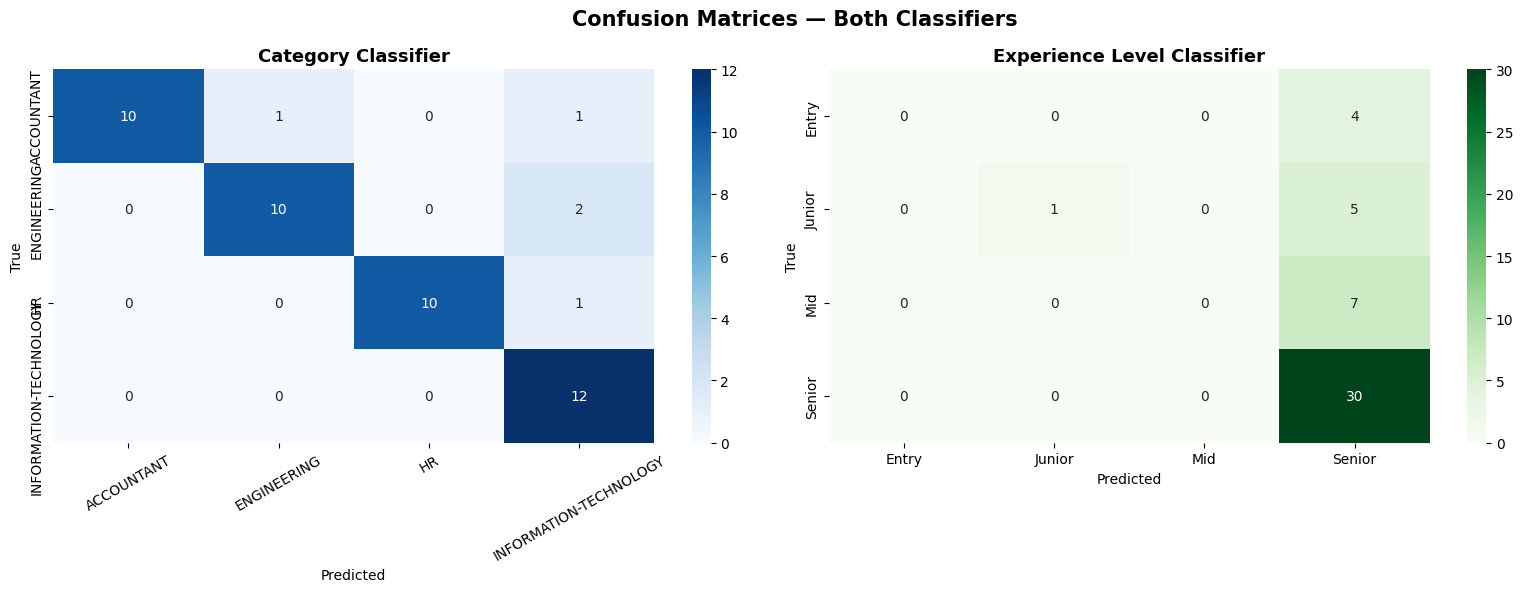

 Saved: confusion_matrices_combined.png


In [6]:
cat_cm = confusion_matrix(y_cat_true, y_cat_pred)
exp_cm = confusion_matrix(y_exp_true, y_exp_pred)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Confusion Matrices — Both Classifiers", fontsize=15, fontweight='bold')

sns.heatmap(cat_cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=cat_encoder.classes_, yticklabels=cat_encoder.classes_)
axes[0].set_title('Category Classifier', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].tick_params(axis='x', rotation=30)

sns.heatmap(exp_cm, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=exp_encoder.classes_, yticklabels=exp_encoder.classes_)
axes[1].set_title('Experience Level Classifier', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()
os.makedirs("../results/plots", exist_ok=True)
plt.savefig("../results/plots/confusion_matrices_combined.png", dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: confusion_matrices_combined.png")

## 6. Matching Results Summary

In [7]:
top1 = matches_df[matches_df['rank'] == 1]

print("=" * 55)
print("RESUME–JOB MATCHING SUMMARY")
print("=" * 55)
print(f"\n  Total job postings matched  : {matches_df['job_id'].nunique():,}")
print(f"  Total resume pool           : {resumes.shape[0]}")
print(f"  Total pairs evaluated       : {matches_df['job_id'].nunique() * resumes.shape[0]:,}")

print(f"\n  Top-1 Score Statistics:")
print(top1['similarity_score'].describe().round(4).to_string())

strong   = (top1['similarity_score'] > 0.30).sum()
moderate = ((top1['similarity_score'] >= 0.15) & (top1['similarity_score'] <= 0.30)).sum()
weak     = (top1['similarity_score'] < 0.15).sum()
total    = len(top1)

print(f"\n  Match Quality Breakdown:")
print(f"   🟢 Strong   (> 0.30)    : {strong:,}  ({strong/total*100:.1f}%)")
print(f"   🟡 Moderate (0.15–0.30) : {moderate:,}  ({moderate/total*100:.1f}%)")
print(f"   🔴 Weak     (< 0.15)    : {weak:,}  ({weak/total*100:.1f}%)")

RESUME–JOB MATCHING SUMMARY

  Total job postings matched  : 50,000
  Total resume pool           : 466
  Total pairs evaluated       : 23,300,000

  Top-1 Score Statistics:
count    50000.0000
mean         0.1968
std          0.1011
min          0.0318
25%          0.1192
50%          0.1767
75%          0.2551
max          0.5371

  Match Quality Breakdown:
   🟢 Strong   (> 0.30)    : 8,255  (16.5%)
   🟡 Moderate (0.15–0.30) : 21,475  (43.0%)
   🔴 Weak     (< 0.15)    : 20,270  (40.5%)


## 7. Unfiltered vs Category-Filtered Score Comparison

Category-filtered matching constrains each job to only resumes from
the relevant domain. Scores may appear lower because generic vocabulary
overlap (e.g. "management", "team") no longer inflates scores across
mismatched domains.

SCORE COMPARISON: Unfiltered vs Filtered

Unfiltered  — Mean : 0.1968 | Median : 0.1767
Filtered    — Mean : 0.1876 | Median : 0.1720


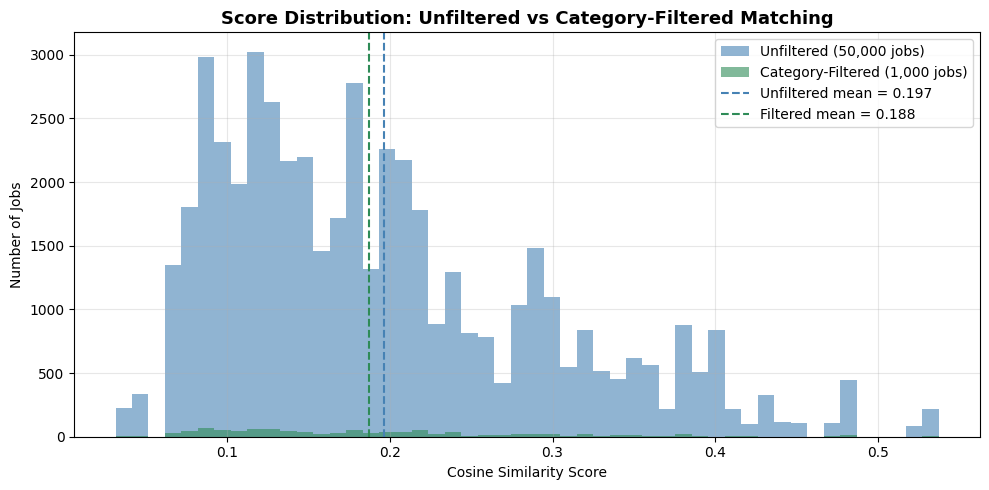

 Saved: unfiltered_vs_filtered_scores.png


In [8]:
unfiltered_top1 = matches_df[matches_df['rank'] == 1]['similarity_score']
filtered_top1   = filtered_df[filtered_df['rank'] == 1]['similarity_score']

print("=" * 50)
print("SCORE COMPARISON: Unfiltered vs Filtered")
print("=" * 50)
print(f"\nUnfiltered  — Mean : {unfiltered_top1.mean():.4f} | Median : {unfiltered_top1.median():.4f}")
print(f"Filtered    — Mean : {filtered_top1.mean():.4f} | Median : {filtered_top1.median():.4f}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(unfiltered_top1, bins=50, alpha=0.6, color='steelblue', label='Unfiltered (50,000 jobs)')
ax.hist(filtered_top1,   bins=50, alpha=0.6, color='seagreen',  label='Category-Filtered (1,000 jobs)')
ax.axvline(unfiltered_top1.mean(), color='steelblue', linestyle='--', linewidth=1.5,
           label=f'Unfiltered mean = {unfiltered_top1.mean():.3f}')
ax.axvline(filtered_top1.mean(),   color='seagreen',  linestyle='--', linewidth=1.5,
           label=f'Filtered mean = {filtered_top1.mean():.3f}')
ax.set_title('Score Distribution: Unfiltered vs Category-Filtered Matching', fontsize=13, fontweight='bold')
ax.set_xlabel('Cosine Similarity Score')
ax.set_ylabel('Number of Jobs')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../results/plots/unfiltered_vs_filtered_scores.png", dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: unfiltered_vs_filtered_scores.png")

## 8. Combined Results Dashboard

A single-figure overview of all key metrics side by side.

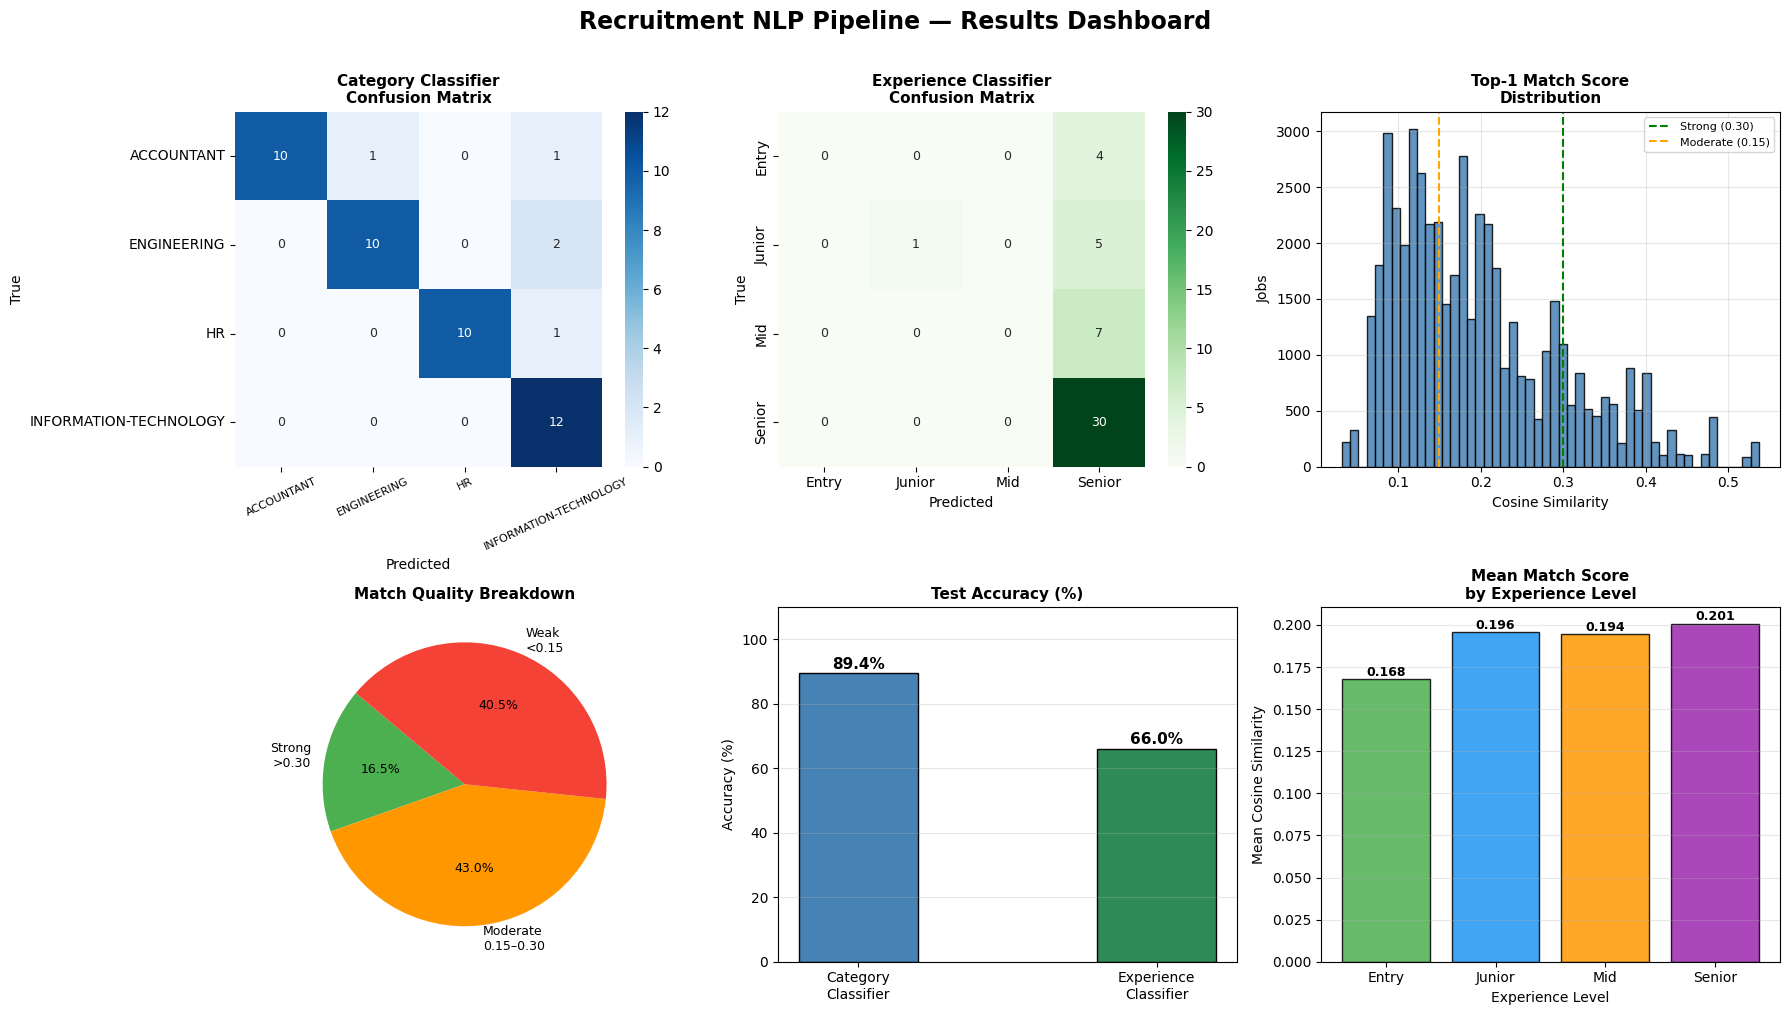

 Saved: results_dashboard.png


In [9]:
fig = plt.figure(figsize=(18, 10))
fig.suptitle("Recruitment NLP Pipeline — Results Dashboard", fontsize=17, fontweight='bold', y=1.01)

# ── Confusion matrix: Category ─────────────────────────────────
ax1 = fig.add_subplot(2, 3, 1)
sns.heatmap(cat_cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=cat_encoder.classes_, yticklabels=cat_encoder.classes_,
            annot_kws={'size': 9})
ax1.set_title('Category Classifier\nConfusion Matrix', fontsize=11, fontweight='bold')
ax1.set_xlabel('Predicted')
ax1.set_ylabel('True')
ax1.tick_params(axis='x', rotation=25, labelsize=8)

# ── Confusion matrix: Experience ───────────────────────────────
ax2 = fig.add_subplot(2, 3, 2)
sns.heatmap(exp_cm, annot=True, fmt='d', cmap='Greens', ax=ax2,
            xticklabels=exp_encoder.classes_, yticklabels=exp_encoder.classes_,
            annot_kws={'size': 9})
ax2.set_title('Experience Classifier\nConfusion Matrix', fontsize=11, fontweight='bold')
ax2.set_xlabel('Predicted')
ax2.set_ylabel('True')

# ── Score distribution ─────────────────────────────────────────
ax3 = fig.add_subplot(2, 3, 3)
ax3.hist(top1['similarity_score'], bins=50, color='steelblue', edgecolor='black', alpha=0.85)
ax3.axvline(0.30, color='green',  linestyle='--', linewidth=1.5, label='Strong (0.30)')
ax3.axvline(0.15, color='orange', linestyle='--', linewidth=1.5, label='Moderate (0.15)')
ax3.set_title('Top-1 Match Score\nDistribution', fontsize=11, fontweight='bold')
ax3.set_xlabel('Cosine Similarity')
ax3.set_ylabel('Jobs')
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3)

# ── Match quality pie ──────────────────────────────────────────
ax4 = fig.add_subplot(2, 3, 4)
ax4.pie([strong, moderate, weak],
        labels=['Strong\n>0.30', 'Moderate\n0.15–0.30', 'Weak\n<0.15'],
        colors=['#4CAF50', '#FF9800', '#f44336'],
        autopct='%1.1f%%', startangle=140, textprops={'fontsize': 9})
ax4.set_title('Match Quality Breakdown', fontsize=11, fontweight='bold')

# ── Classifier accuracy bar ────────────────────────────────────
ax5 = fig.add_subplot(2, 3, 5)
classifiers = ['Category\nClassifier', 'Experience\nClassifier']
accuracies  = [cat_acc * 100, exp_acc * 100]
colors_bar  = ['steelblue', 'seagreen']
bars = ax5.bar(classifiers, accuracies, color=colors_bar, edgecolor='black', width=0.4)
ax5.set_ylim(0, 110)
ax5.set_title('Test Accuracy (%)', fontsize=11, fontweight='bold')
ax5.set_ylabel('Accuracy (%)')
ax5.grid(axis='y', alpha=0.3)
for bar, acc in zip(bars, accuracies):
    ax5.text(bar.get_x() + bar.get_width()/2, acc + 1.5,
             f'{acc:.1f}%', ha='center', fontsize=11, fontweight='bold')

# ── Score by experience level ──────────────────────────────────
ax6 = fig.add_subplot(2, 3, 6)
level_order  = ['Entry', 'Junior', 'Mid', 'Senior']
level_colors = ['#4CAF50', '#2196F3', '#FF9800', '#9C27B0']
top1_exp = top1[top1['experience_level'].notna()]
mean_scores = top1_exp.groupby('experience_level')['similarity_score'].mean()
mean_scores = mean_scores.reindex([l for l in level_order if l in mean_scores.index])
bars2 = ax6.bar(mean_scores.index, mean_scores.values,
                color=level_colors[:len(mean_scores)], edgecolor='black', alpha=0.85)
ax6.set_title('Mean Match Score\nby Experience Level', fontsize=11, fontweight='bold')
ax6.set_xlabel('Experience Level')
ax6.set_ylabel('Mean Cosine Similarity')
ax6.grid(axis='y', alpha=0.3)
for bar, val in zip(bars2, mean_scores.values):
    ax6.text(bar.get_x() + bar.get_width()/2, val + 0.002,
             f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig("../results/plots/results_dashboard.png", dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: results_dashboard.png")

## 9. Key Observations

### 9.1 Data
- The resume dataset is **small (466 filtered rows)** across 4 categories. BatchNormalization
  and Dropout help the model generalize despite limited training data.
- Job description text averages only **24 words** — enriching with `skills` and
  `Responsibilities` columns was essential for meaningful vectorization.
- Only **26.5% vocabulary overlap** between resume and job TF-IDF vocabularies confirms
  that resumes and job postings use different language conventions.

### 9.2 Keyword Extraction
- Each domain has clearly distinct keyword profiles:
  **HR** -> 'recruitment', 'payroll', 'employee' |
  **ACCOUNTANT** -> 'financial', 'tax', 'audit' |
  **ENGINEERING** -> 'mechanical', 'design', 'technical' |
  **IT** -> 'python', 'software', 'network'
- Bigrams (e.g. 'machine learning', 'project management') added meaningful signal
  over single-word features.

### 9.3 Classification
- The **category classifier** benefits from a near-balanced dataset (~115 samples/class).
- The **experience classifier** faced severe class imbalance (Senior = 64%).
  `compute_class_weight('balanced')` and `batch_size=16` partially corrected this.
- Experience labels were inferred (not ground truth) — this introduces label noise
  and limits the experience classifier's ceiling.

### 9.4 Matching
- Category-filtered matching produces **domain-relevant** shortlists. Lower average
  scores are expected because domain-specific vocabulary is less generic.
- **Senior resumes** tend to score highest due to richer vocabulary and longer text.
- TF-IDF matching is lexical only — it cannot detect semantic similarity
  (e.g., 'software engineer' ≠ 'developer' in TF-IDF space).

## 10. Suggestions for Improvement

| Area | Suggestion | Expected Impact |
|---|---|---|
| Data | Collect 500+ labeled resumes per category | Higher classifier accuracy |
| Embeddings | Replace TF-IDF with sentence-transformers (`all-MiniLM-L6-v2`) | Better semantic matching |
| Matching | Use FAISS approximate nearest-neighbor on embeddings | Scalable to millions |
| Experience labels | Use structured data (LinkedIn API / manual labels) | Cleaner classifier |
| Architecture | Add LSTM or Transformer layers | Capture word order & context |
| Class imbalance | Apply SMOTE to minority experience levels | Improve Entry/Junior recall |
| Evaluation | Collect recruiter feedback as match ground truth | Enable supervised matching |

## 11. Final Pipeline Summary

| Notebook | Task | Key Output |
|---|---|---|
| 01 | Data Exploration | Distributions, word count stats, missing value analysis |
| 02 | Preprocessing | `resumes_cleaned.csv`, `jobs_cleaned.csv` |
| 03 | Keyword Extraction | TF-IDF matrices, word clouds, keyword bar charts |
| 04 | Classification | Category MLP (acc%), Experience MLP (acc%), confusion matrices |
| 05 | Matching | 23.3M pair cosine similarity, top-5 matches per job |
| 06 | Summary Report | Consolidated metrics, dashboard, observations |

### Architecture
```
Input (5,000 TF-IDF features)
  -> Dense(512, ReLU) -> BatchNorm -> Dropout(0.4)
  -> Dense(256, ReLU) -> BatchNorm -> Dropout(0.3)
  -> Dense(128, ReLU) -> BatchNorm -> Dropout(0.3)
  -. Dense(4, Softmax)
```

### Matching Pipeline
```
Resume Text --> preprocess --> shared TF-IDF (8K features) --> cosine similarity --> top-5 matches
Job Text    --> preprocess ──/
```

In [11]:
print("=" * 60)
print("PIPELINE COMPLETE — NLP PROJECT")
print("=" * 60)
print(f"""
  Notebooks run     : 01 -> 06
  Resumes processed : {resumes.shape[0]}
  Jobs processed    : {jobs.shape[0]:,}
  Pairs evaluated   : {matches_df['job_id'].nunique() * resumes.shape[0]:,}

  Category Classifier Accuracy  : {cat_acc*100:.2f}%
  Experience Classifier Accuracy: {exp_acc*100:.2f}%

  Mean top-1 match score (unfiltered) : {unfiltered_top1.mean():.4f}
  Mean top-1 match score (filtered)   : {filtered_top1.mean():.4f}

  All results saved to:
    results/plots/     — PNG visualizations
    results/metrics/   — CSV match results
    results/models/    — Keras model weights
""")

PIPELINE COMPLETE — NLP PROJECT

  Notebooks run     : 01 -> 06
  Resumes processed : 466
  Jobs processed    : 50,000
  Pairs evaluated   : 23,300,000

  Category Classifier Accuracy  : 89.36%
  Experience Classifier Accuracy: 65.96%

  Mean top-1 match score (unfiltered) : 0.1968
  Mean top-1 match score (filtered)   : 0.1876

  All results saved to:
    results/plots/     — PNG visualizations
    results/metrics/   — CSV match results
    results/models/    — Keras model weights

